In [1]:
import os
import re
import json
import pandas as pd
import numpy as np
from tqdm import tqdm
from datetime import datetime

import seaborn as sns
from matplotlib import pyplot as plt
from matplotlib.colors import BoundaryNorm
from matplotlib.colors import ListedColormap


from patsy import dmatrices
import bambi as bmb
import arviz as az
from scipy.stats import chi2
import statsmodels.api as sm
import matplotlib.pyplot as plt
from IPython.display import display
import statsmodels.formula.api as smf
from scipy.stats import chi2_contingency
from statsmodels.stats.multitest import multipletests
from statsmodels.stats.outliers_influence import variance_inflation_factor

from util import *

sns.set_palette('colorblind')

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

In [2]:
peacock_urls = [
    'https://www.instagram.com/peacock/reel/DSEC7pojf3H/',
    'https://www.instagram.com/peacock/reel/DSEFSQJAGeV/',
    'https://www.instagram.com/peacock/p/DSD45vFgDBd/',
    'https://www.instagram.com/peacock/reel/DSDUvgsgLqk/',
    'https://www.instagram.com/belairpeacock/reel/DSDOHnBCS0t/',
    'https://www.instagram.com/nbc/reel/DSDOHj2kr00/',
    'https://www.instagram.com/spotify/reel/DSDN0oCDkGb/',
    'https://www.instagram.com/peacock/p/DSDAUdIgDUw/',
    'https://www.instagram.com/peacock/reel/DSBm_S8gC1p/',
    'https://www.instagram.com/peacock/reel/DSBZZEcgL4D/',
]

nytcooking_urls = [
    'https://www.instagram.com/nytcooking/reel/DSD_gy1DcX5/',
    'https://www.instagram.com/nytcooking/p/DSDwcgkk1qn/',
    'https://www.instagram.com/nytcooking/p/DSDitvpAZUH/',
    'https://www.instagram.com/nytcooking/p/DSDb1UoknQg/',
    'https://www.instagram.com/nytcooking/p/DSDU8zokpV3/',
    'https://www.instagram.com/nytcooking/p/DSDOaPWk4bv/',
    'https://www.instagram.com/nytcooking/p/DSDSO3Fkwax/',
    'https://www.instagram.com/nytcooking/reel/DSDNChjDjIB/',
    'https://www.instagram.com/nytcooking/p/DSC_QAgks4q/',
    'https://www.instagram.com/nytcooking/p/DSDBAbzjifA/',
]

espn_urls = [
    'https://www.instagram.com/espn/reel/DSEgVgeAPWE/',
    'https://www.instagram.com/espncfb/p/DSEWMX5jGnh/',
    'https://www.instagram.com/espn/reel/DSEVBjZAOdU/',
    'https://www.instagram.com/espn/p/DSEOlBoDCRb/',
    'https://www.instagram.com/espn/p/DSEMouEjLXr/',
    'https://www.instagram.com/espn/p/DSELB0fjEiG/',
    'https://www.instagram.com/espn/p/DSEIW-zjJXe/',
    'https://www.instagram.com/espn/p/DSD6pTxgdJv/',
    'https://www.instagram.com/espn/p/DSDrfEyDxs-/',
    'https://www.instagram.com/espn/p/DSDjBkeEiVo/',
]

catloversclub_urls = [
    'https://www.instagram.com/catloversclub/reel/DSEn813Eo5Q/',
    'https://www.instagram.com/catloversclub/reel/DSEHOC8kufg/',
    'https://www.instagram.com/catloversclub/p/DSDzLhlkniQ/',
    'https://www.instagram.com/catloversclub/p/DSC60BKkrYV/',
    'https://www.instagram.com/catloversclub/reel/DSBk9RQEmtF/',
    'https://www.instagram.com/catloversclub/p/DSBQuBCEg6f/',
    'https://www.instagram.com/catloversclub/p/DSARqDnEhPJ/',
    'https://www.instagram.com/catloversclub/p/DR_mqpKEr01/',
    'https://www.instagram.com/catloversclub/reel/DR_fCEnEmtA/',
    'https://www.instagram.com/catloversclub/p/DR-_MPRkurr/',
]

thedogist_urls = [
    'https://www.instagram.com/thedogist/p/DSDe6u8kS6O/',
    'https://www.instagram.com/thedogist/reel/DR-aHhzkXgF/',
    'https://www.instagram.com/thedogist/reel/DR72mfKEedE/',
    'https://www.instagram.com/empirestatebldg/reel/DR7aTBTkebB/',
    'https://www.instagram.com/thedogist/p/DR5O3P_jycm/',
    'https://www.instagram.com/thedogist/reel/DR4mTwyESDm/',
    'https://www.instagram.com/thedogist/reel/DR2VEONkdPT/',
    'https://www.instagram.com/thedogist/reel/DRw-IF6EaT_/',
    'https://www.instagram.com/thedogist/p/DRqGWbcEVvW/',
    'https://www.instagram.com/thedogist/reel/DRnCa95EcVk/',
]

thegradecricketer = [
    'https://www.instagram.com/thegradecricketer/reel/DSEuOIXEsI6/',
    'https://www.instagram.com/thegradecricketer/reel/DSERcMKEs-k/',
    'https://www.instagram.com/thegradecricketer/reel/DSEC3JekvxZ/',
    'https://www.instagram.com/thegradecricketer/reel/DSCJfZ8jKrQ/',
    'https://www.instagram.com/kayosports/reel/DSB-wRmE6MH/',
    'https://www.instagram.com/triplemcricket/reel/DR_3mtdjCre/',
    'https://www.instagram.com/thegradecricketer/reel/DR_CMYYku_p/',
    'https://www.instagram.com/thegradecricketer/reel/DR9nU3FkhGV/',
    'https://www.instagram.com/thegradecricketer/reel/DR7tgNXgCeL/',
    'https://www.instagram.com/thegradecricketer/reel/DR5bFbrgFP0/',
]

pbsfood_urls = [
    'https://www.instagram.com/pbsfood/reel/DSC5fCjiBkw/',
    'https://www.instagram.com/pbsfood/p/DSAwJ9ZjgfK/',
    'https://www.instagram.com/pbsfood/p/DR99nxribK5/',
    'https://www.instagram.com/pbssocal/reel/DR2_SXGlN-b/',
    'https://www.instagram.com/pbsfood/p/DR2tagbj4NN/',
    'https://www.instagram.com/pbsfood/reel/DRzxYwWFLrA/',
    'https://www.instagram.com/pbsfood/p/DRr1KVSDQDY/',
    'https://www.instagram.com/pbsfood/p/DRmrnTCj0Uc/',
    'https://www.instagram.com/pbsfood/reel/DRkSd-jAfYR/',
    'https://www.instagram.com/pbsfood/p/DRkATf0DWKW/',
]

hulu_urls = [
    'https://www.instagram.com/hulu/reel/DSD-0GpEVyJ/',
    'https://www.instagram.com/hulu/reel/DSDb1_QCpwm/',
    'https://www.instagram.com/hulu/p/DSDPdCDja0P/',
    'https://www.instagram.com/hulu/reel/DSDAUFlkyrO/',
    'https://www.instagram.com/percyseries/reel/DSDNXoPjue0/',
    'https://www.instagram.com/freeform/reel/DSAz8SxDsaI/',
    'https://www.instagram.com/hulu/p/DSBtohckS3R/',
    'https://www.instagram.com/kumailn/reel/DSBN7auEbAo/',
    'https://www.instagram.com/hulu/reel/DSBAnzeFae5/',
    'https://www.instagram.com/getspectrum/reel/DSA91c8EeIY/',
]

ladbible_urls = [
    'https://www.instagram.com/ladbible/p/DSCrwGuDxUR/',
    'https://www.instagram.com/ladbible/reel/DSCoNYQDAK-/',
    'https://www.instagram.com/ladbible/p/DSCd_wJABTo/',
    'https://www.instagram.com/ladbible/p/DSA3Yh7ACwc/',
    'https://www.instagram.com/sportbible/p/DSAzKDHjI_T/',
    'https://www.instagram.com/sportbible/p/DSAwJA8kctO/',
    'https://www.instagram.com/ladbible/reel/DSApUwzlTf_/',
    'https://www.instagram.com/ladbible/p/DSAic0ZEhfR/',
    'https://www.instagram.com/ladbible/p/DSAYaLiE0TC/',
    'https://www.instagram.com/ladbible/p/DSAG9sXk1Fn/',
]

accesshollywood_urls = [
    'https://www.instagram.com/accesshollywood/reel/DSEBiASCUPH/',
    'https://www.instagram.com/accesshollywood/p/DSD1KHYkXtU/',
    'https://www.instagram.com/accesshollywood/reel/DSDirU6EkO2/',
    'https://www.instagram.com/accesshollywood/p/DSDU9GlDmn4/',
    'https://www.instagram.com/accesshollywood/reel/DSDKXfBCjPl/',
    'https://www.instagram.com/accesshollywood/p/DSC5lsdkySq/',
    'https://www.instagram.com/accesshollywood/reel/DSB-0hjkQNx/',
    'https://www.instagram.com/accesshollywood/reel/DSBnCAXiIL3/',
    'https://www.instagram.com/accesshollywood/reel/DSBZVIJjRta/',
    'https://www.instagram.com/accesshollywood/p/DSBAeqRk4is/',
]

all_urls = {
    'peacock': peacock_urls,
    'nytcooking': nytcooking_urls,
    'espn': espn_urls,
    'catloversclub': catloversclub_urls,
    'thedogist': thedogist_urls,
    'thegradecricketer': thegradecricketer,
    'pbsfood': pbsfood_urls,
    'hulu': hulu_urls,
    'ladbible': ladbible_urls,
    'accesshollywood': accesshollywood_urls
}

In [3]:
all_crawls = ['ny_1', 'texas_1',
              'male_dem_ny_1', 'male_dem_texas_1',
              'male_rep_ny_1', 'male_rep_texas_1',
              'female_dem_ny_1', 'female_dem_texas_1',
              'female_rep_ny_1', 'female_rep_texas_1']

# all_crawls = ['ny_1',
#               'male_dem_ny_1',
#               'male_rep_ny_1',
#               'female_dem_ny_1',
#               'female_rep_ny_1']

file_path = '/Users/brahmaninutakki/saarland/insta-comments/saved_data/new'

### Merging and preprocessing

In [4]:
dfs = {}
for crawl in all_crawls:
    temp_list = []
    for account in all_urls.keys():

        accountfiles = os.listdir(f'{file_path}/{crawl}/{account}')
        file_ids = list({re.split(r'_(comments|timestamps)', fp)[0] for fp in accountfiles})

        for id_ in file_ids:

            # if both comments and timestamps files are present
            if f'{id_}_comments.json' in accountfiles and f'{id_}_timestamps.json' in accountfiles:

                with open(f'{file_path}/{crawl}/{account}/{id_}_comments.json', 'r') as f:
                    comments = json.load(f)
                with open(f'{file_path}/{crawl}/{account}/{id_}_timestamps.json', 'r') as f:
                    timestamps = json.load(f)
                
                caption, comments, likes = clean_comments(comments)

                # this particular comment is just ' '. so adding it manually.
                id_user_mapping = {
                    'DRVQXcWAaaw': 'authoryuccaharris',
                    'DSBZZEcgL4D': 'mafia__460mafia_', 
                    'DSBm_S8gC1p': 'grimreaper3716',
                    'DRYdTZHjT-E': 'danieleichenlaub',
                    'DSARqDnEhPJ': 'amadeoedgardof',
                    'DR_mqpKEr01': 'amadeoedgardof',
                    'DSC60BKkrYV': 'amadeoedgardof',
                    'DR5O3P_jycm': 'dottyeroth',
                    'DSCrwGuDxUR': 'treqpimento_',
                    'DSEn813Eo5Q': 'amadeoedgardof'

                }

                if id_ in id_user_mapping:
                    if id_user_mapping[id_] in comments:
                        idx = comments.index(id_user_mapping[id_])
                        comments = comments[:idx+1] + [' '] + comments[idx+1:]

                # mapping usernames and comments to timestamps
                comments_map = {}

                # checking if comments (username + comment) and timestamps are of same length 
                if len(comments) == 2*len(timestamps):

                    if len(comments) % 2 == 0:

                        usernames = comments[::2]
                        comments_text = comments[1::2]

                        
                        for u, c, t in zip(usernames, comments_text, timestamps):
                            comments_map[(u, c)] = t

                        idx = 0
                        for c, v in comments_map.items():
                            temp_dict = {'account': account,
                                         'urlid': id_,
                                         'caption': caption,
                                         'comment_num': idx,
                                         f'{crawl}_comment': c,
                                         f'{crawl}_timestamp': v,
                                         'likes': likes} # TODO: check if likes here is correct
                            idx += 1
                            temp_list.append(temp_dict)

                else:
                    # if this happens, its mostly happening since a comment is empty string ''
                    print(f'comemnts-timestamps length mismatch', account, id_, crawl)
            else:
                # only comments file is present
                with open(f'{file_path}/{crawl}/{account}/{id_}_comments.json', 'r') as f:
                    comments = json.load(f)

                caption, comments, likes = clean_comments(comments)
                if len(comments) != 0:
                    if id_ == 'DSC60BKkrYV':
                        caption, comments, likes = None, [], None
                    else:
                        print('no timestamp file and len(comments) != 0', id_, account, crawl, len(comments))
                    
                    # if this happens its usually to do more cleaning of comements

    df = pd.DataFrame(temp_list)
    dfs[crawl] = df

In [5]:
for crawl, df in dfs.items():
    print(f'{crawl}: {df.shape}')

ny_1: (1100, 7)
texas_1: (1025, 7)
male_dem_ny_1: (1087, 7)
male_dem_texas_1: (1118, 7)
male_rep_ny_1: (1114, 7)
male_rep_texas_1: (1098, 7)
female_dem_ny_1: (1095, 7)
female_dem_texas_1: (1087, 7)
female_rep_ny_1: (1082, 7)
female_rep_texas_1: (1080, 7)


In [6]:
for crawl, df in dfs.items():
    df.drop(columns=['caption', 'likes'], inplace=True, axis=1)

In [7]:
merged_df = dfs['ny_1'].copy()

for crawl, df in dfs.items():
    if crawl == 'ny_1':
        continue
    print(crawl)
    merged_df = pd.merge(merged_df, df, how='outer', on=['account', 'urlid', 'comment_num'])

texas_1
male_dem_ny_1
male_dem_texas_1
male_rep_ny_1
male_rep_texas_1
female_dem_ny_1
female_dem_texas_1
female_rep_ny_1
female_rep_texas_1


In [8]:
# remove urls that have less than 10 comments

urlids = merged_df['urlid'].unique().tolist()
donotremove_urls = set()
for urlid in urlids:
    temp = merged_df[merged_df['urlid'] == urlid]
    num_rows = temp['comment_num'].max()
    if num_rows <= 8:
        continue
    else:
        donotremove_urls.add(urlid)

merged_df = merged_df[merged_df['urlid'].isin(donotremove_urls)]

In [9]:
# limiting to top 10 comments
merged_df = merged_df[merged_df['comment_num'] <= 9]
merged_df.shape

(770, 23)

In [10]:
temp_df = get_chronological_order_comments(merged_df, all_urls, all_crawls)
merged_df = pd.merge(merged_df, temp_df, how='outer', on=['account', 'urlid', 'comment_num'])

In [11]:
merged_df.drop(columns=[x for x in merged_df.columns if 'timestamp' in x], inplace=True)
merged_df.head()

,account,urlid,comment_num,ny_1_comment,texas_1_comment,male_dem_ny_1_comment,male_dem_texas_1_comment,male_rep_ny_1_comment,male_rep_texas_1_comment,female_dem_ny_1_comment,female_dem_texas_1_comment,female_rep_ny_1_comment,female_rep_texas_1_comment,chronological_comment
0,accesshollywood,DSB-0hjkQNx,0,"(ericalex06, 😂😂😂😂👏👏)","(ericalex06, 😂😂😂😂👏👏)","(ericalex06, 😂😂😂😂👏👏)","(ericalex06, 😂😂😂😂👏👏)","(ericalex06, 😂😂😂😂👏👏)","(ericalex06, 😂😂😂😂👏👏)","(ericalex06, 😂😂😂😂👏👏)","(ericalex06, 😂😂😂😂👏👏)","(ericalex06, 😂😂😂😂👏👏)","(ericalex06, 😂😂😂😂👏👏)","(debmarie5, Why so much orange on him)"
1,accesshollywood,DSB-0hjkQNx,1,"(mindi.bro, Pickleball?)","(mindi.bro, Pickleball?)","(mindi.bro, Pickleball?)","(mindi.bro, Pickleball?)","(mindi.bro, Pickleball?)","(mindi.bro, Pickleball?)","(mindi.bro, Pickleball?)","(mindi.bro, Pickleball?)","(timothee_chalamet_mx, 🔥❤️😍)","(timothee_chalamet_mx, 🔥❤️😍)","(timothee_chalamet_mx, 🔥❤️😍)"
2,accesshollywood,DSB-0hjkQNx,2,"(timothee_chalamet_mx, 🔥❤️😍)","(timothee_chalamet_mx, 🔥❤️😍)","(timothee_chalamet_mx, 🔥❤️😍)","(timothee_chalamet_mx, 🔥❤️😍)","(timothee_chalamet_mx, 🔥❤️😍)","(timothee_chalamet_mx, 🔥❤️😍)","(timothee_chalamet_mx, 🔥❤️😍)","(timothee_chalamet_mx, 🔥❤️😍)","(mindi.bro, Pickleball?)","(mindi.bro, Pickleball?)","(ericalex06, 😂😂😂😂👏👏)"
3,accesshollywood,DSB-0hjkQNx,3,"(persona_tiffany, I love it 👏👏)","(persona_tiffany, I love it 👏👏)","(persona_tiffany, I love it 👏👏)","(persona_tiffany, I love it 👏👏)","(persona_tiffany, I love it 👏👏)","(persona_tiffany, I love it 👏👏)","(persona_tiffany, I love it 👏👏)","(persona_tiffany, I love it 👏👏)","(growing_up_with_timothee, Definitely 😍🧡)","(growing_up_with_timothee, Definitely 😍🧡)","(taosphotogirl22, Clearly, yes, we do.)"
4,accesshollywood,DSB-0hjkQNx,4,"(growing_up_with_timothee, Definitely 😍🧡)","(growing_up_with_timothee, Definitely 😍🧡)","(growing_up_with_timothee, Definitely 😍🧡)","(growing_up_with_timothee, Definitely 😍🧡)","(growing_up_with_timothee, Definitely 😍🧡)","(growing_up_with_timothee, Definitely 😍🧡)","(growing_up_with_timothee, Definitely 😍🧡)","(growing_up_with_timothee, Definitely 😍🧡)","(persona_tiffany, I love it 👏👏)","(persona_tiffany, I love it 👏👏)","(persona_tiffany, I love it 👏👏)"


In [12]:
merged_df.shape

(1054, 14)

### Plotting differences

In [13]:
crawl1 = 'chronological'
crawl2 = 'texas_1'

temp_df = merged_df.copy()
account_fprops_no_rank, account_fprops_rank, temp_df = compute_fprops(crawl1, crawl2, temp_df, all_urls)

division by zero espn DSEWMX5jGnh 0 0
division by zero espn DSEgVgeAPWE 0 0
division by zero catloversclub DSDzLhlkniQ 0 0
division by zero thedogist DR72mfKEedE 0 0
division by zero hulu DSDPdCDja0P 0 0
division by zero ladbible DSAzKDHjI_T 0 0
division by zero ladbible DSCoNYQDAK- 0 0
division by zero ladbible DSCrwGuDxUR 0 0
division by zero accesshollywood DSD1KHYkXtU 0 0


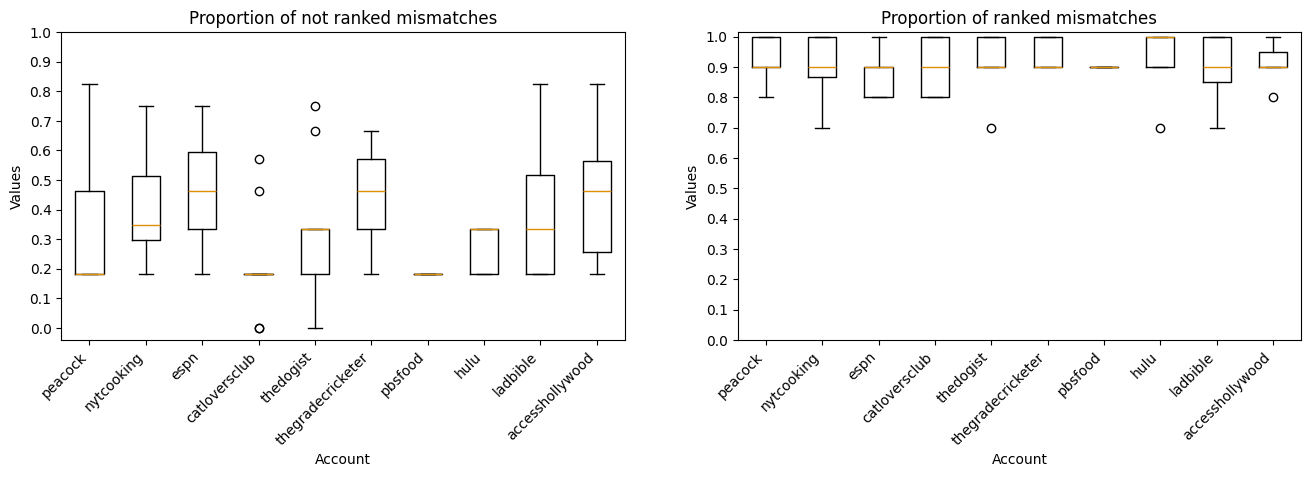

In [14]:
accounts = list(account_fprops_no_rank.keys())
values_no_rank = [account_fprops_no_rank[acc] for acc in accounts]
values_rank = [account_fprops_rank[acc] for acc in accounts]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 4))

ax1.boxplot(values_no_rank, tick_labels=accounts)
ax1.set_title("Proportion of not ranked mismatches")
ax1.set_xlabel("Account")
ax1.set_ylabel("Values")
ax1.set_xticks(range(1, 11))
ax1.set_xticklabels(accounts, rotation=45, ha='right')
ax1.set_yticks(np.arange(0, 1.1, 0.1))

ax2.boxplot(values_rank, tick_labels=accounts)
ax2.set_title("Proportion of ranked mismatches")
ax2.set_xlabel("Account")
ax2.set_ylabel("Values")
ax2.set_xticks(range(1, 11))
ax2.set_xticklabels(accounts, rotation=45, ha='right')
ax2.set_yticks(np.arange(0, 1.1, 0.1))

plt.show()

In [ ]:
mismatch_no_rank, mismatch_rank = {}, {}

for crawl1 in ['chronological'] + all_crawls:
    mismatch_no_rank[crawl1] = {}
    mismatch_rank[crawl1] = {}
    for crawl2 in all_crawls:
        mod_df = merged_df.copy()
        _, _, mod_df = compute_fprops(crawl1, crawl2, mod_df, all_urls)

        temp_df = mod_df[mod_df['comment_num'] == 0]
        mismatch_no_rank[crawl1][crawl2] = temp_df['fcount_no_rank'].sum() / temp_df['ftrials_no_rank'].sum()
        mismatch_rank[crawl1][crawl2] = temp_df['fcount_rank'].sum() / temp_df['ftrials_rank'].sum()

mismatch_rank_df = pd.DataFrame.from_dict(mismatch_rank, orient="index")
mismatch_no_rank_df = pd.DataFrame.from_dict(mismatch_no_rank, orient="index")

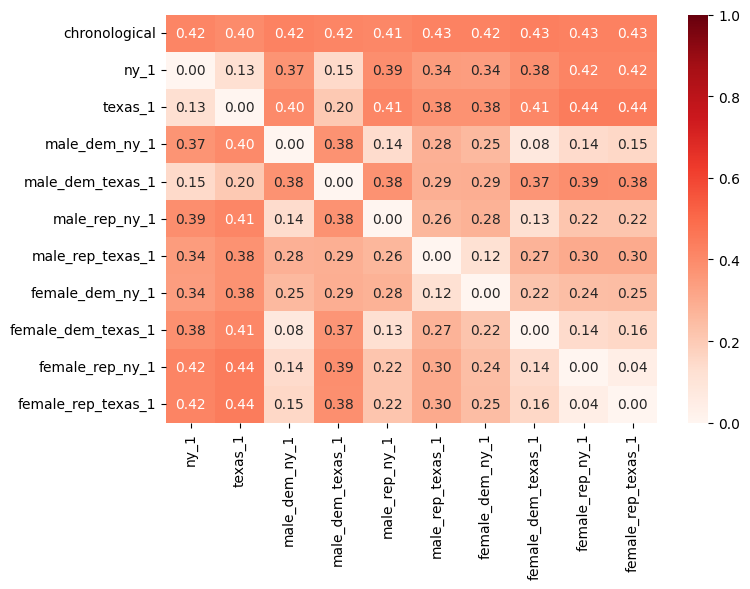

In [16]:
plt.figure(figsize=(8, 6)) 
sns.heatmap(mismatch_no_rank_df, annot=True, fmt=".2f", cmap="Reds", vmin=0, vmax=1)
plt.tight_layout()
plt.show()

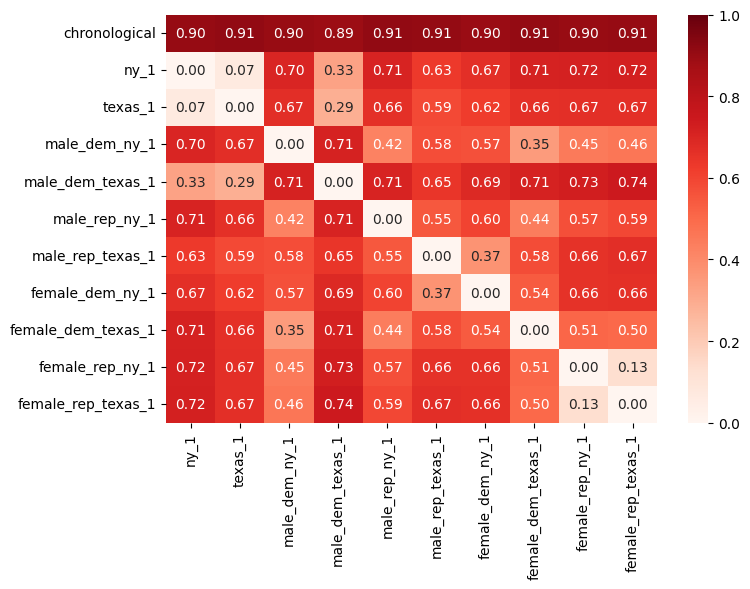

In [17]:
plt.figure(figsize=(8, 6)) 
sns.heatmap(mismatch_rank_df, annot=True, fmt=".2f", cmap="Reds", vmin=0, vmax=1)
plt.tight_layout()
plt.show()

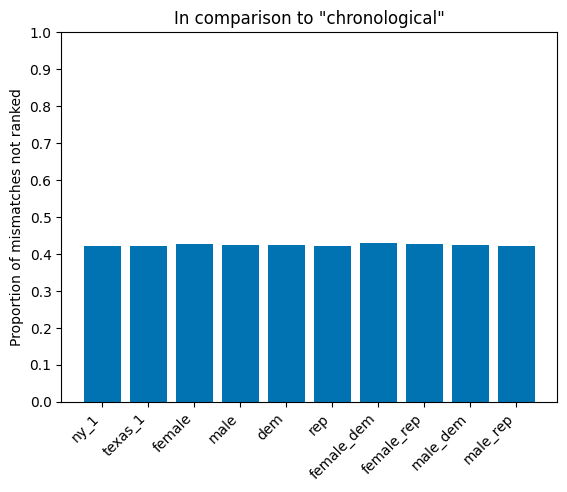

In [18]:
condensed_mismatches_no_rank = {}
individual_labels = ['ny_1', 'texas_1', 'female', 'male', 'dem', 'rep',
                     'female_dem', 'female_rep', 'male_dem', 'male_rep']
base_label = 'chronological'
pattern = r'(?P<gender>male|female)_(?P<ideo>dem|rep)_(?P<loc>ny|texas)'


for x in individual_labels:
    vals = []
    for crawl in ['chronological'] + all_crawls:
        matches = re.search(pattern, crawl)
        groups = matches.groupdict() if matches else {}
        if crawl == 'chronological':
            groups = {'chronological': 'chronological'}
        if base_label in groups.values():
            for label, val in mismatch_no_rank_df.T[crawl].to_dict().items():
                if x in label:
                    vals.append(val)

    try:
        condensed_mismatches_no_rank[x] = sum(vals) / len(vals)
    except ZeroDivisionError:
        condensed_mismatches_no_rank[x] = None


plt.bar(range(len(condensed_mismatches_no_rank)), list(condensed_mismatches_no_rank.values()))
plt.xticks(range(len(condensed_mismatches_no_rank)), list(condensed_mismatches_no_rank.keys()), rotation=45, ha='right')
plt.yticks(np.arange(0, 1.1, 0.1))
plt.title(f'In comparison to "{base_label}"')
plt.ylabel('Proportion of mismatches not ranked')
plt.show()

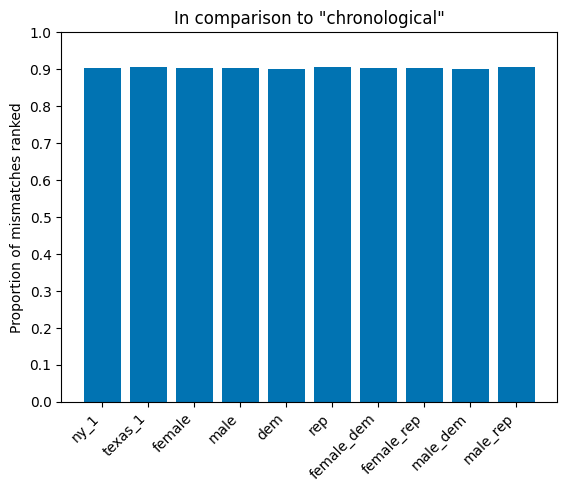

In [19]:
condensed_mismatches_rank = {}
individual_labels = ['ny_1', 'texas_1', 'female', 'male', 'dem', 'rep',
                     'female_dem', 'female_rep', 'male_dem', 'male_rep']
base_label = 'chronological'
pattern = r'(?P<gender>male|female)_(?P<ideo>dem|rep)_(?P<loc>ny|texas)'


for x in individual_labels:
    vals = []
    for crawl in ['chronological'] + all_crawls:
        matches = re.search(pattern, crawl)
        groups = matches.groupdict() if matches else {}
        if crawl == 'chronological':
            groups = {'chronological': 'chronological'}
        if base_label in groups.values():
            for label, val in mismatch_rank_df.T[crawl].to_dict().items():
                if x in label:
                    vals.append(val)

    try:
        condensed_mismatches_rank[x] = sum(vals) / len(vals)
    except ZeroDivisionError:
        condensed_mismatches_rank[x] = None


plt.bar(range(len(condensed_mismatches_rank)), list(condensed_mismatches_rank.values()))
plt.xticks(range(len(condensed_mismatches_rank)), list(condensed_mismatches_rank.keys()), rotation=45, ha='right')
plt.yticks(np.arange(0, 1.1, 0.1))
plt.title(f'In comparison to "{base_label}"')
plt.ylabel('Proportion of mismatches ranked')
plt.show()

#### Old graphs

In [ ]:
# col1 = 'chronological_comment'
# col2 = 'ny_1_comment'
# col3 = 'texas_1_comment'
# col4 = 'male_dem_ny_1_comment'
# col5 = 'male_dem_texas_1_comment'
# col6 = 'male_rep_ny_1_comment'
# col7 = 'male_rep_texas_1_comment'
# col8 = 'female_dem_ny_1_comment'
# col9 = 'female_dem_texas_1_comment' 
# col10 = 'female_rep_ny_1_comment'
# col11 = 'female_rep_texas_1_comment'

# cols = [col1, col2, col3, col4, col5,
#         col6, col7, col8, col9, col10, col11]

# # col1 = 'chronological_comment'
# # col2 = 'ny_1_comment'
# # col3 = 'male_dem_ny_1_comment'
# # col4 = 'male_rep_ny_1_comment'
# # col5 = 'female_dem_ny_1_comment'
# # col6 = 'female_rep_ny_1_comment'

# # cols = [col1, col2, col3, col4, col5,
# #         col6]


# codes = []
# for idx, x in zip(merged_df.index, zip(*(merged_df[c] for c in cols))):

#     temp_code = []
#     for i, a in enumerate(x):
#         if pd.isna(a):
#             code = -1
#         else:
#             acc_comments = []
            
#             if i == 0:
#                 remove_col = col1
#             elif i == 1:
#                 remove_col = col2
#             elif i == 2:
#                 remove_col = col3
#             elif i == 3:
#                 remove_col = col4
#             elif i == 4:
#                 remove_col = col5
#             elif i == 5:
#                 remove_col = col6
#             elif i == 6:
#                 remove_col = col7
#             elif i == 7:
#                 remove_col = col8
#             elif i == 8:
#                 remove_col = col9
#             elif i == 9:
#                 remove_col = col10
#             elif i == 10:
#                 remove_col = col11

#             for c in cols:
#                 if c == remove_col:
#                     continue
#                 if c == col1:
#                     continue
#                 acc = merged_df.loc[idx, 'account']
#                 url = merged_df.loc[idx, 'urlid']
#                 acc_comments += merged_df[(merged_df['account'] == acc) & (merged_df['urlid'] == url)][c].dropna().unique().tolist() 

#             if a in set(acc_comments):
#                 code = 0
#             else:
#                 code = 1

#         temp_code.append(code)
#     codes.append(temp_code)

# codes = np.array(codes)

# max_code = codes[codes >= 0].max() if np.any(codes >= 0) else -1
# num_groups = max_code + 1

# base_cmap = plt.cm.YlOrBr(np.linspace(0, 1, max(num_groups, 1)))
# colors = np.vstack(([0.85, 0.85, 0.85, 1.0], base_cmap))
# cmap = ListedColormap(colors)

# bounds = np.arange(-1.5, num_groups + 0.5, 1)
# norm = BoundaryNorm(bounds, cmap.N)

# fig, ax = plt.subplots(figsize=(6, 6))

# sns.heatmap(
#     codes,
#     annot=False,
#     cmap=cmap,
#     norm=norm,
#     vmin=-1,
#     vmax=max_code,
#     cbar=True,                      
#     linewidths=0,
#     yticklabels=False,
#     xticklabels=[c.replace('_comment', '') for c in cols],
#     ax=ax
# )

# ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
# cbar = ax.collections[0].colorbar
# cbar.set_ticks([-1, 0, 1])
# cbar.set_ticklabels([
#     "-1",
#     "0",
#     "1",
# ])

# # optional: add dotted separators for groups (your urlid trick)
# # indices = merged_df["urlid"].drop_duplicates().index
# # for y in indices:
# #     ax.hlines(y, *ax.get_xlim(), linestyles="dotted", linewidth=1, color="black")

# plt.tight_layout()
# plt.show()


In [ ]:
# key_cols = ["account", "urlid"]

# group_comments = {}
# for key, g in merged_df.groupby(key_cols, sort=False):
#     group_comments[key] = {
#         col: set(g[col].dropna())
#         for col in cols
#     }

# overall_not_covered = pd.DataFrame(index=cols, columns=cols, dtype=float)

# for c1 in cols:
#     for c2 in cols:
#         if c1 == c2:
#             overall_not_covered.loc[c1, c2] = 0.0
#             continue

#         total = 0
#         not_covered = 0

#         for key, d in group_comments.items():
#             s1 = d[c1]
#             s2 = d[c2]
#             if not s1:
#                 continue

#             total += len(s1)
#             not_covered += len(s1 - s2)

#         overall_not_covered.loc[c1, c2] = not_covered / total if total else 0.0



# fig, ax = plt.subplots(figsize=(8, 6))

# im = ax.imshow(
#     overall_not_covered.values,
#     aspect='auto',
#     cmap='Reds',
#     vmin=0, vmax=1
# )

# ax.set_xticks(range(len(cols)))
# ax.set_yticks(range(len(cols)))
# ax.set_xticklabels(cols, rotation=45, ha='right')
# ax.set_yticklabels(cols)

# for i in range(len(cols)):
#     for j in range(len(cols)):
#         ax.text(j, i, f"{overall_not_covered.iloc[i, j]:.2f}",
#                 ha='center', va='center', fontsize=8)

# cbar = fig.colorbar(im, ax=ax, cmap='Blues')
# cbar.set_label('Proportion of False (mismatch)')

# plt.tight_layout()
# plt.show()


In [ ]:
# codes = []
# for x in zip(*(merged_df[c] for c in cols)):
#     present_already = []
#     temp_code = []
#     for a in x:
#         if pd.isna(a):
#             c = -1
#         else:
#             if a not in present_already:
#                 c = len(present_already)
#                 present_already.append(a)
#             else:
#                 c = present_already.index(a)
#         temp_code.append(c)
#     codes.append(temp_code)

# codes = np.array(codes)

# max_code = codes[codes >= 0].max() if np.any(codes >= 0) else -1
# num_groups = max_code + 1

# base_cmap = plt.cm.YlOrBr(np.linspace(0, 1, max(num_groups, 1)))
# colors = np.vstack(([0.85, 0.85, 0.85, 1.0], base_cmap))
# cmap = ListedColormap(colors)

# bounds = np.arange(-1.5, num_groups + 0.5, 1)
# norm = BoundaryNorm(bounds, cmap.N)

# fig, ax = plt.subplots(figsize=(6, 6))

# sns.heatmap(
#     codes,
#     annot=False,
#     cmap=cmap,
#     norm=norm,
#     vmin=-1,
#     vmax=max_code,
#     cbar=False,                      
#     linewidths=0,
#     yticklabels=False,
#     xticklabels=[c.replace('_comment', '') for c in cols],
#     ax=ax
# )

# ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

# # optional: add dotted separators for groups (your urlid trick)
# # indices = merged_df["urlid"].drop_duplicates().index
# # for y in indices:
# #     ax.hlines(y, *ax.get_xlim(), linestyles="dotted", linewidth=1, color="black")

# plt.tight_layout()
# plt.show()


In [ ]:
# false_ratio = pd.DataFrame(index=cols, columns=cols, dtype=float)

# for c1 in cols:
#     for c2 in cols:
#         if c1 == c2:
#             false_ratio.loc[c1, c2] = 0.0
#         else:
#             comp = merged_df[c1] == merged_df[c2]
#             false_ratio.loc[c1, c2] = (~comp).mean()
#             false_ratio.loc[c2, c1] = false_ratio.loc[c1, c2]


# fig, ax = plt.subplots(figsize=(8, 6))

# im = ax.imshow(
#     false_ratio.values,
#     aspect='auto',
#     cmap='Reds',
#     vmin=0, vmax=1
# )

# ax.set_xticks(range(len(cols)))
# ax.set_yticks(range(len(cols)))
# ax.set_xticklabels(cols, rotation=45, ha='right')
# ax.set_yticklabels(cols)

# for i in range(len(cols)):
#     for j in range(len(cols)):
#         ax.text(j, i, f"{false_ratio.iloc[i, j]:.2f}",
#                 ha='center', va='center', fontsize=8)

# cbar = fig.colorbar(im, ax=ax, cmap='Blues')
# cbar.set_label('Proportion of False (mismatch)')

# plt.tight_layout()
# plt.show()


### Regression Analysis

In [ ]:
reg_nonpol_df = pd.DataFrame(columns=['account', 'urlid', 'gender', 'ideology', 'fcount_no_rank', 'ftrials_no_rank', 'fcount_rank', 'ftrials_rank'])

temp_list = []
for crawl1 in ['chronological'] + all_crawls:
    for crawl2 in all_crawls:

        if crawl1 == crawl2:
            continue

        temp_dict = {}

        _, _, merged_df = compute_fprops(crawl1, crawl2, merged_df, all_urls)
        temp_df = merged_df[['account', 'urlid', 'fcount_no_rank', 'ftrials_no_rank', 'fcount_rank', 'ftrials_rank']].drop_duplicates()

        gender, ideology, location = compute_label_reg(crawl1, crawl2)

        temp_dict['location'] = location
        temp_dict['gender'] = gender
        temp_dict['ideology'] = ideology

        for index, row in temp_df.iterrows():
            temp_dict['urlid'] = row['urlid']
            temp_dict['account'] = row['account']
            temp_dict['fcount_no_rank'] = row['fcount_no_rank']
            temp_dict['ftrials_no_rank'] = row['ftrials_no_rank']
            temp_dict['fcount_rank'] = row['fcount_rank'] 
            temp_dict['ftrials_rank'] = row['ftrials_rank']
            temp_list.append(temp_dict.copy())


reg_nonpol_df = pd.DataFrame(temp_list)       
reg_nonpol_df.shape

In [14]:
reg_nonpol_df.drop_duplicates(inplace=True)
reg_nonpol_df.shape

(4088, 9)

In [15]:
reg_nonpol_df.dropna(inplace=True, subset=['ftrials_rank'])
reg_nonpol_df.shape

(4082, 9)

In [16]:
accounts_data = pd.read_excel('/Users/brahmaninutakki/saarland/insta-comments/News Sites US.xlsx', sheet_name='Reduced_NonPolitical_Accounts')
accounts_data.head(3)

,account,posts,followers,following
0,peacock,7450,2400000,122
1,nytcooking,13648,4600000,167
2,espn,68799,28400000,539


In [17]:
reg_nonpol_df = pd.merge(reg_nonpol_df, accounts_data, on='account', how='inner')
reg_nonpol_df.shape

(4082, 12)

In [18]:
reg_pol_df = pd.read_csv('/Users/brahmaninutakki/saarland/insta-comments/regression_data_political.csv')

In [19]:
reg_pol_df

,location,gender,ideology,urlid,account,fcount_no_rank,ftrials_no_rank,fcount_rank,ftrials_rank,political_ideology,reporting_quality,credibility,posts,followers,following,main_topic,posts_log,followers_log,following_log
0,none_ny,none_none,none_none,DRWBiQXDG0H,breitbart,2,11,8,10,Right,Mixed,Low,34864.0,1800000,362,Political,10.459239,14.403298,5.894403
1,none_ny,none_none,none_none,DRWXFT9DRtK,breitbart,8,14,9,10,Right,Mixed,Low,34864.0,1800000,362,Political,10.459239,14.403298,5.894403
2,none_ny,none_none,none_none,DRWhnmjDo-i,breitbart,8,14,10,10,Right,Mixed,Low,34864.0,1800000,362,Political,10.459239,14.403298,5.894403
3,none_ny,none_none,none_none,DRXIibxjFKK,breitbart,6,13,10,10,Right,Mixed,Low,34864.0,1800000,362,Political,10.459239,14.403298,5.894403
4,none_ny,none_none,none_none,DRXUNHfDYvW,breitbart,6,13,10,10,Right,Mixed,Low,34864.0,1800000,362,Non-Political,10.459239,14.403298,5.894403
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4337,ny_texas,female_female,rep_rep,DRX-31ODa_2,washingtonpost,0,10,4,10,Center-Left,Mostly Factual,High,24022.0,7300000,187,Non-Political,10.086767,15.803385,5.236442
4338,ny_texas,female_female,rep_rep,DRXO1Q9Co1Y,washingtonpost,0,10,0,10,Center-Left,Mostly Factual,High,24022.0,7300000,187,Non-Political,10.086767,15.803385,5.236442
4339,ny_texas,female_female,rep_rep,DRXf-IGj2TH,washingtonpost,0,10,2,10,Center-Left,Mostly Factual,High,24022.0,7300000,187,Non-Political,10.086767,15.803385,5.236442
4340,ny_texas,female_female,rep_rep,DRXw_eDjr9l,washingtonpost,0,10,0,10,Center-Left,Mostly Factual,High,24022.0,7300000,187,Non-Political,10.086767,15.803385,5.236442


In [20]:
reg_pol_df.drop(columns=['political_ideology', 'reporting_quality', 'credibility', 'main_topic'], inplace=True)
reg_pol_df

,location,gender,ideology,urlid,account,fcount_no_rank,ftrials_no_rank,fcount_rank,ftrials_rank,posts,followers,following,posts_log,followers_log,following_log
0,none_ny,none_none,none_none,DRWBiQXDG0H,breitbart,2,11,8,10,34864.0,1800000,362,10.459239,14.403298,5.894403
1,none_ny,none_none,none_none,DRWXFT9DRtK,breitbart,8,14,9,10,34864.0,1800000,362,10.459239,14.403298,5.894403
2,none_ny,none_none,none_none,DRWhnmjDo-i,breitbart,8,14,10,10,34864.0,1800000,362,10.459239,14.403298,5.894403
3,none_ny,none_none,none_none,DRXIibxjFKK,breitbart,6,13,10,10,34864.0,1800000,362,10.459239,14.403298,5.894403
4,none_ny,none_none,none_none,DRXUNHfDYvW,breitbart,6,13,10,10,34864.0,1800000,362,10.459239,14.403298,5.894403
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4337,ny_texas,female_female,rep_rep,DRX-31ODa_2,washingtonpost,0,10,4,10,24022.0,7300000,187,10.086767,15.803385,5.236442
4338,ny_texas,female_female,rep_rep,DRXO1Q9Co1Y,washingtonpost,0,10,0,10,24022.0,7300000,187,10.086767,15.803385,5.236442
4339,ny_texas,female_female,rep_rep,DRXf-IGj2TH,washingtonpost,0,10,2,10,24022.0,7300000,187,10.086767,15.803385,5.236442
4340,ny_texas,female_female,rep_rep,DRXw_eDjr9l,washingtonpost,0,10,0,10,24022.0,7300000,187,10.086767,15.803385,5.236442


In [21]:
reg_pol_df['type'] = 'Political'
reg_nonpol_df['type'] = 'Non-Political'

In [22]:
concat_df = pd.concat([reg_nonpol_df, reg_pol_df], ignore_index=True)
concat_df.shape

(8424, 16)

In [23]:
concat_df['fcount_no_rank'] = concat_df['fcount_no_rank'].astype(int)
concat_df['ftrials_no_rank'] = concat_df['ftrials_no_rank'].astype(int)
concat_df['fcount_rank'] = concat_df['fcount_rank'].astype(int)
concat_df['ftrials_rank'] = concat_df['ftrials_rank'].astype(int)

(concat_df[concat_df['fcount_no_rank'] > concat_df['ftrials_no_rank']]).shape, (concat_df[concat_df['fcount_rank'] > concat_df['ftrials_rank']]).shape

((0, 16), (0, 16))

In [24]:
# concat_df["gender_ideology"] = pd.Categorical(
#     reg_df["gender_ideology"],
#     categories=["none_none_ny", "none_none_texas", "male_dem_ny", "male_dem_texas", "male_rep_ny", "male_rep_texas",
#                 "female_dem_ny", "female_dem_texas", "female_rep_ny", "female_rep_texas"],
#     ordered=True
# )

# reg_df["gender_ideology"] = pd.Categorical(
#     reg_df["gender_ideology"],
#     categories=["male_dem", "male_rep", "female_dem", "female_rep"],
#     # categories=["none_none", "male_dem", "male_rep", "female_dem", "female_rep"],
#     ordered=True
# )

for col in ["posts", "followers", "following"]:
    # reg_df[col + "_z"] = (reg_df[col] - reg_df[col].mean()) / reg_df[col].std()
    concat_df[col + "_log"] = np.log1p(concat_df[col])

concat_df["gender"] = pd.Categorical(
    concat_df["gender"],
    categories=["none_none", "none_female", "none_male", "female_female", "female_male", "male_male"],
    ordered=True
)

concat_df["ideology"] = pd.Categorical(
    concat_df["ideology"],
    categories=["none_none", "none_dem", "none_rep", "dem_dem", "dem_rep", "rep_rep"],
    ordered=True
)

concat_df["location"] = pd.Categorical(
    concat_df["location"],
    categories=["none_ny", "none_texas", "ny_ny", "ny_texas", "texas_texas"],
    ordered=True
)

concat_df['type'] = pd.Categorical(concat_df['type'], categories=['Non-Political', 'Political'], ordered=True)

In [25]:
concat_df[["posts", "followers", "following"]].corr()

,posts,followers,following
posts,1.000000,0.430338,-0.081003
followers,0.430338,1.000000,-0.192373
following,-0.081003,-0.192373,1.000000


In [26]:
concat_df.shape

(8424, 16)

In [27]:
concat_df.head()

,location,gender,ideology,urlid,account,fcount_no_rank,ftrials_no_rank,fcount_rank,ftrials_rank,posts,followers,following,type,posts_log,followers_log,following_log
0,none_ny,none_none,none_none,DSB-0hjkQNx,accesshollywood,4,12,10,10,28864.0,1800000,1470,Non-Political,10.270385,14.403298,7.293698
1,none_ny,none_none,none_none,DSBAeqRk4is,accesshollywood,14,17,10,10,28864.0,1800000,1470,Non-Political,10.270385,14.403298,7.293698
2,none_ny,none_none,none_none,DSC5lsdkySq,accesshollywood,6,13,8,10,28864.0,1800000,1470,Non-Political,10.270385,14.403298,7.293698
3,none_ny,none_none,none_none,DSD1KHYkXtU,accesshollywood,4,12,8,10,28864.0,1800000,1470,Non-Political,10.270385,14.403298,7.293698
4,none_ny,none_none,none_none,DSDKXfBCjPl,accesshollywood,6,13,9,10,28864.0,1800000,1470,Non-Political,10.270385,14.403298,7.293698


In [30]:
formula = "fcount_no_rank ~ C(location) + C(gender) + C(ideology) + C(type) + posts_log + followers_log + following_log" 
formula = "fcount_no_rank ~ C(location) + C(ideology) + C(type) + posts_log + followers_log + following_log" 
get_vif(formula, concat_df)

,feature,VIF
10,C(type)[T.Political],1.015038
12,following_log,1.034033
11,followers_log,1.041905
1,C(location)[T.none_texas],1.809217
2,C(location)[T.ny_ny],2.794539
4,C(location)[T.texas_texas],2.799821
9,C(ideology)[T.rep_rep],2.994037
7,C(ideology)[T.dem_dem],3.008671
3,C(location)[T.ny_texas],3.740932
6,C(ideology)[T.none_rep],3.890576


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [Intercept, location, gender, ideology, type, posts_log, followers_log, following_log, 1|account_sigma, 1|account_offset]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 707 seconds.


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
Intercept,-1.032,1.052,-3.061,0.914,0.013,0.016,6762.0,4751.0,1.0
location[none_texas],-0.005,0.029,-0.057,0.051,0.000,0.000,9319.0,6294.0,1.0
location[ny_ny],-0.306,0.029,-0.361,-0.252,0.000,0.000,9721.0,6626.0,1.0
location[ny_texas],-0.350,0.026,-0.402,-0.302,0.000,0.000,9316.0,6126.0,1.0
location[texas_texas],-0.158,0.029,-0.212,-0.104,0.000,0.000,9785.0,6454.0,1.0
gender[none_female],0.250,0.501,-0.675,1.216,0.006,0.006,7258.0,5663.0,1.0
gender[none_male],0.145,0.501,-0.793,1.092,0.006,0.006,7236.0,5387.0,1.0
gender[female_female],-0.566,0.407,-1.357,0.170,0.006,0.004,4528.0,4947.0,1.0
gender[female_male],-0.109,0.406,-0.857,0.665,0.006,0.004,4528.0,5097.0,1.0
gender[male_male],0.038,0.406,-0.731,0.791,0.006,0.004,4501.0,5212.0,1.0


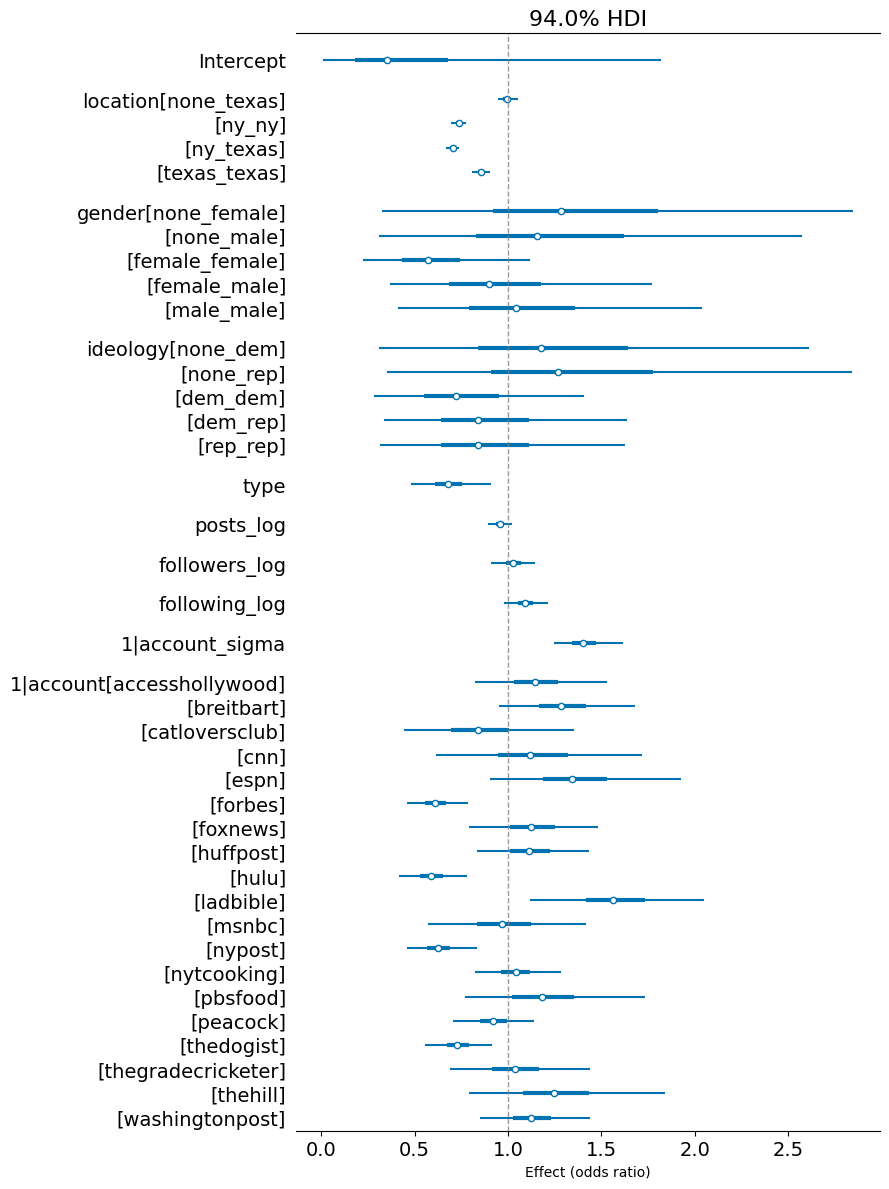

In [31]:
model = bmb.Model(
    "p(fcount_no_rank, ftrials_no_rank) ~ location + gender + ideology + type + posts_log + followers_log + following_log + (1|account)",
    data=concat_df,
    family="binomial",
    # dropna=True
)

results = model.fit(
    draws=2000,      
    tune=2000,       
    target_accept=0.97,
    chains=4,
    cores=4,
)
display(az.summary(results))

axes = az.plot_forest(
    results,
    combined=True,
    hdi_prob=0.94,
    transform=np.exp,
    figsize=(9, 12),
    r_hat=False,
    ess=False,
)

ax = axes[0] if isinstance(axes, (list, np.ndarray)) else axes

ax.axvline(1, linestyle="--", linewidth=1, color="grey", alpha=0.8)
ax.set_xlabel("Effect (odds ratio)")
plt.tight_layout()
plt.show()

Initializing NUTS using jitter+adapt_diag...
Sequential sampling (4 chains in 1 job)
NUTS: [Intercept, location, ideology, type, posts_log, followers_log, following_log, 1|account_sigma, 1|account_offset]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 1221 seconds.


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
Intercept,-1.033,1.064,-2.990,1.018,0.013,0.015,7127.0,4670.0,1.0
location[none_texas],-0.005,0.029,-0.060,0.049,0.000,0.000,9413.0,6493.0,1.0
location[ny_ny],-0.302,0.029,-0.355,-0.249,0.000,0.000,8610.0,6373.0,1.0
location[ny_texas],-0.358,0.026,-0.406,-0.310,0.000,0.000,8550.0,6351.0,1.0
location[texas_texas],-0.151,0.028,-0.205,-0.098,0.000,0.000,8404.0,6231.0,1.0
ideology[none_dem],0.357,0.034,0.293,0.422,0.000,0.000,8138.0,5650.0,1.0
ideology[none_rep],0.435,0.034,0.367,0.495,0.000,0.000,8109.0,5378.0,1.0
ideology[dem_dem],-0.473,0.042,-0.556,-0.397,0.000,0.001,7875.0,5636.0,1.0
ideology[dem_rep],-0.343,0.037,-0.412,-0.272,0.000,0.001,7988.0,4906.0,1.0
ideology[rep_rep],-0.316,0.042,-0.391,-0.236,0.000,0.001,7977.0,5529.0,1.0


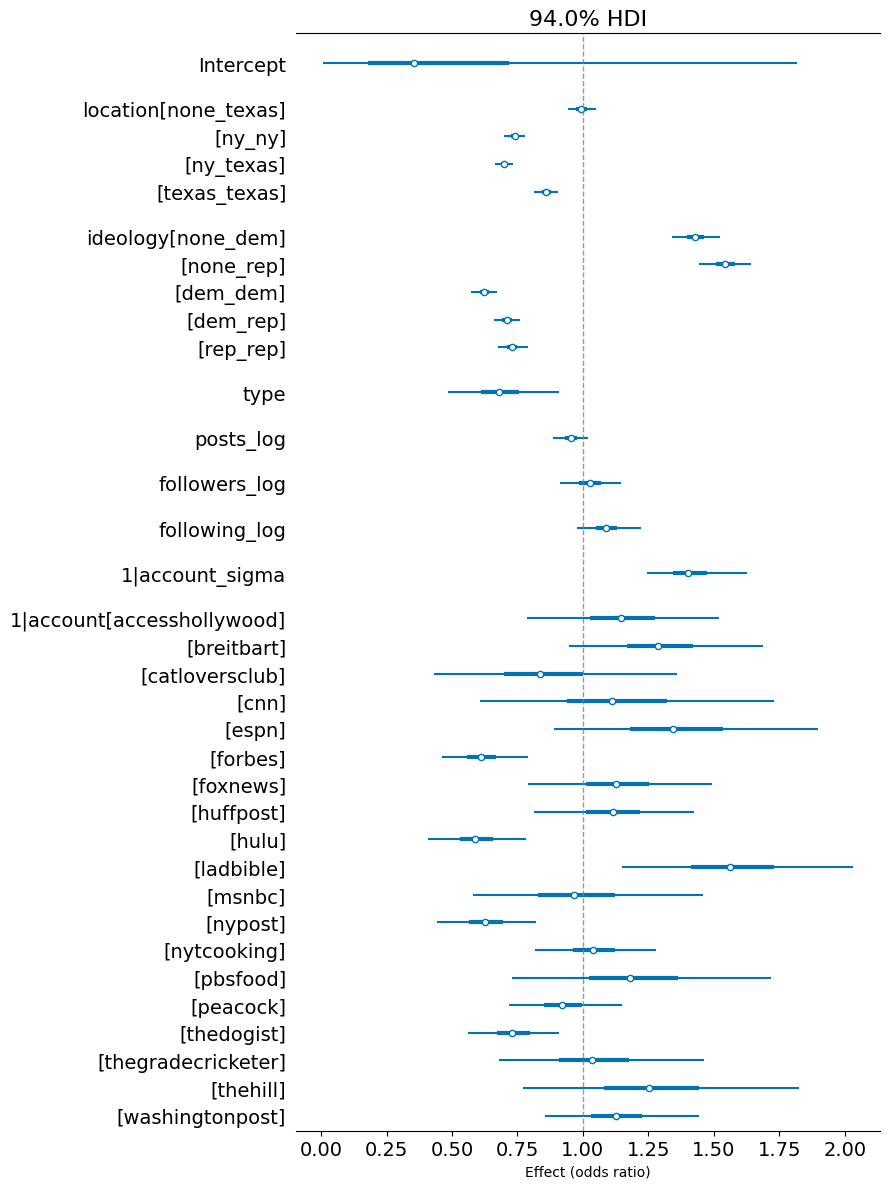

In [33]:
model = bmb.Model(
    "p(fcount_no_rank, ftrials_no_rank) ~ location + ideology + type + posts_log + followers_log + following_log + (1|account)",
    data=concat_df,
    family="binomial",
    # dropna=True
)

results = model.fit(
    draws=2000,      
    tune=2000,       
    target_accept=0.97,
    chains=4,
    cores=1
)
display(az.summary(results))

axes = az.plot_forest(
    results,
    combined=True,
    hdi_prob=0.94,
    transform=np.exp,
    figsize=(9, 12),
    r_hat=False,
    ess=False,
)

ax = axes[0] if isinstance(axes, (list, np.ndarray)) else axes

ax.axvline(1, linestyle="--", linewidth=1, color="grey", alpha=0.8)
ax.set_xlabel("Effect (odds ratio)")
plt.tight_layout()
plt.show()

Initializing NUTS using jitter+adapt_diag...
Sequential sampling (4 chains in 1 job)
NUTS: [Intercept, location, gender, type, posts_log, followers_log, following_log, 1|account_sigma, 1|account_offset]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 1220 seconds.


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
Intercept,-1.035,1.049,-3.158,0.833,0.013,0.015,6535.0,5075.0,1.0
location[none_texas],-0.005,0.030,-0.062,0.051,0.000,0.000,9739.0,5899.0,1.0
location[ny_ny],-0.303,0.029,-0.359,-0.249,0.000,0.000,9538.0,6933.0,1.0
location[ny_texas],-0.355,0.027,-0.406,-0.306,0.000,0.000,9098.0,5668.0,1.0
location[texas_texas],-0.154,0.029,-0.209,-0.101,0.000,0.000,9403.0,6383.0,1.0
gender[none_female],0.449,0.035,0.383,0.514,0.000,0.000,8041.0,6402.0,1.0
gender[none_male],0.344,0.035,0.277,0.407,0.000,0.000,8218.0,5913.0,1.0
gender[female_female],-0.762,0.044,-0.843,-0.676,0.000,0.000,8168.0,6423.0,1.0
gender[female_male],-0.320,0.037,-0.388,-0.247,0.000,0.000,8080.0,4880.0,1.0
gender[male_male],-0.159,0.041,-0.232,-0.076,0.000,0.000,7333.0,5162.0,1.0


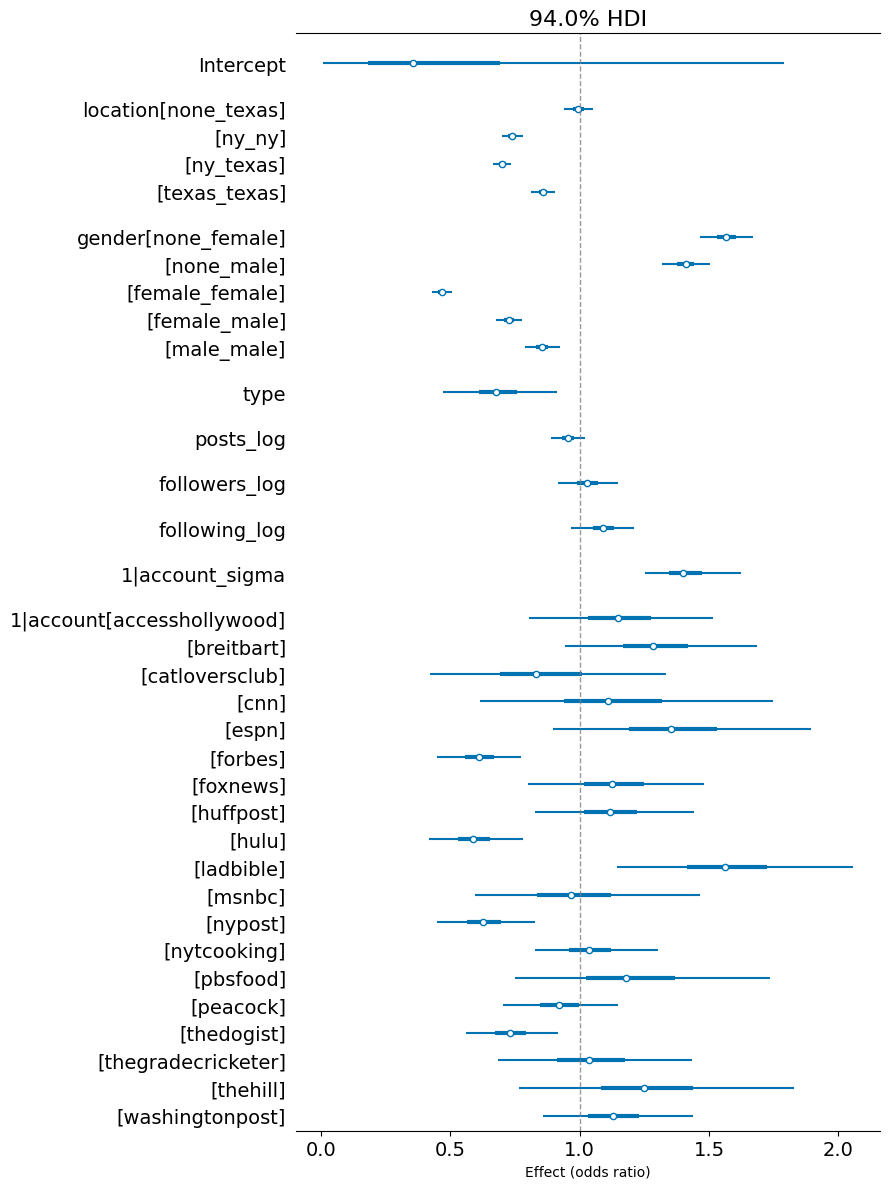

In [34]:
model = bmb.Model(
    "p(fcount_no_rank, ftrials_no_rank) ~ location + gender + type + posts_log + followers_log + following_log + (1|account)",
    data=concat_df,
    family="binomial",
    # dropna=True
)

results = model.fit(
    draws=2000,      
    tune=2000,       
    target_accept=0.97,
    chains=4,
    cores=1
)
display(az.summary(results))

axes = az.plot_forest(
    results,
    combined=True,
    hdi_prob=0.94,
    transform=np.exp,
    figsize=(9, 12),
    r_hat=False,
    ess=False,
)

ax = axes[0] if isinstance(axes, (list, np.ndarray)) else axes

ax.axvline(1, linestyle="--", linewidth=1, color="grey", alpha=0.8)
ax.set_xlabel("Effect (odds ratio)")
plt.tight_layout()
plt.show()